In [41]:
from sklearn.preprocessing import MinMaxScaler , StandardScaler
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.feature_selection import SelectKBest , f_regression
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df_new = pd.read_csv("Final_Data.csv")
df_new

,Property_Area,Bedrooms,Bathrooms,Floors,Year_Built,Property_Age,Lot_Size,Distance_to_City_Center,Neighborhood_Quality_Score,Crime_Rate_Index,...,Water_Supply_Reliability,Electricity_Supply_Reliability,Internet_Availability_Score,Green_Space_Availability_Index,Flood_Risk_Index,Noise_Pollution_Level,Price,Renovation_Status_Yes,Property_Type_Independent House,Property_Type_Villa
0,2684.821829,5,5,2,2018,7,3776.225833,33.354414,8,35.239294,...,4,5,8,51.585174,42.269855,51.872234,1.203248e+07,True,True,False
1,1772.507662,1,1,1,1970,55,3343.248191,21.896193,5,63.487365,...,3,5,8,36.729241,66.331214,66.489083,7.425842e+06,False,False,False
2,1655.959623,2,1,1,2015,10,2856.909759,25.358405,2,83.749235,...,3,5,10,20.020779,79.023068,68.119671,5.734560e+06,False,False,False
3,1655.979127,1,1,1,1976,49,2998.753552,22.062582,6,55.247941,...,9,2,4,40.894197,53.745498,60.449037,8.258959e+06,True,False,False
4,3153.592273,6,5,2,2002,23,4064.463530,35.406036,10,20.723259,...,10,10,9,91.836212,19.668196,53.206428,1.445879e+07,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8705,2302.741825,2,2,1,1994,31,3766.541599,10.708116,9,30.634170,...,7,6,2,72.799026,36.744778,43.506769,1.173157e+07,False,False,True
8706,1373.561786,3,3,2,1994,31,2271.349068,11.949866,4,58.222542,...,9,3,8,25.805114,89.150722,66.396883,6.458641e+06,False,False,True
8707,1191.319333,2,2,2,2022,3,2748.265662,23.944225,2,84.525293,...,10,4,8,0.000000,91.177488,76.934267,4.891362e+06,False,True,False
8708,2811.384485,6,5,1,1970,55,4906.370154,7.170758,8,35.927063,...,1,8,7,54.362379,47.010666,53.486149,1.353664e+07,False,False,True


In [43]:
x = df_new.drop('Price' , axis=1)
y = df_new['Price']

In [44]:
x_train  , x_test , y_train , y_test = train_test_split( x , y , test_size = 0.4 , random_state = 42)

In [45]:
#Although all Columns are Already Numeric , Dummy Columns (Encoded Columns) are NOT to be Scaled

num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if x_train[col].nunique() > 2]
num_cols

['Property_Area',
 'Bedrooms',
 'Bathrooms',
 'Floors',
 'Year_Built',
 'Property_Age',
 'Lot_Size',
 'Distance_to_City_Center',
 'Neighborhood_Quality_Score',
 'Crime_Rate_Index',
 'Nearby_School_Rating',
 'Hospital_Proximity_km',
 'Shopping_Center_Proximity_km',
 'Public_Transport_Accessibility',
 'Construction_Quality_Rating',
 'Energy_Efficiency_Score',
 'Water_Supply_Reliability',
 'Electricity_Supply_Reliability',
 'Internet_Availability_Score',
 'Green_Space_Availability_Index',
 'Flood_Risk_Index',
 'Noise_Pollution_Level']

In [46]:
#Scaling The Data
scale = StandardScaler()
x_train[num_cols] = scale.fit_transform(x_train[num_cols])
x_test[num_cols] = scale.fit_transform(x_test[num_cols])

In [80]:
model = ElasticNet(max_iter = 10000)

In [81]:
kbest = SelectKBest(score_func=f_regression, k=15)

In [82]:
x_new = kbest.fit_transform(x_train , y_train)
x_test_new = kbest.transform(x_test)

In [83]:
param_grid = {
    'alpha': [0.05, 0.1, 0.2],
    'l1_ratio': [0.3, 0.5, 0.8]
}

In [84]:
grid = GridSearchCV(model, param_grid, cv=5, scoring='r2')
grid.fit(x_new, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet(max_iter=10000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.05, 0.1, ...], 'l1_ratio': [0.3, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [85]:
best_model = grid.best_estimator_
print(grid.best_params_)

{'alpha': 0.05, 'l1_ratio': 0.8}


In [86]:
param_grid2 = {
    'alpha': [0.05, 0.07, 0.02],
    'l1_ratio': [0.85, 0.9, 0.8]
}

In [87]:
grid2 = GridSearchCV(model, param_grid2 , cv=5, scoring='r2')
grid2.fit(x_new, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet(max_iter=10000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.05, 0.07, ...], 'l1_ratio': [0.85, 0.9, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

In [88]:
best_model2 = grid2.best_estimator_
print(grid2.best_params_)

{'alpha': 0.02, 'l1_ratio': 0.9}


In [89]:
y_pred = best_model2.predict(x_test_new)
y_pred

array([12026855.73435469, 13089203.34446716, 16983880.39568293, ...,
        7976138.49033931,  6677286.23062199,  4146311.1370862 ],
      shape=(3484,))

In [90]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

mean_y = y.mean()

print("Mean of target:", mean_y)
print("RMSE %:", (rmse / mean_y) * 100)
print("MAE %:", (mae / mean_y) * 100)

print("Min:", y.min())
print("Max:", y.max())
print("Mean:", y.mean())

RMSE: 890680.9362393441
MAE: 713388.3763642234
Mean of target: 8500408.637934167
RMSE %: 10.478095514897552
MAE %: 8.39240096270944
Min: 756202.795535137
Max: 21574662.602344614
Mean: 8500408.637934167


In [91]:
r2 = r2_score(y_test , y_pred) 
print("R2 Score : " , r2)

R2 Score :  0.9554229564754776


In [92]:
y_train_pred = best_model2.predict(x_new)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9568946823140658
Test R2: 0.9554229564754776


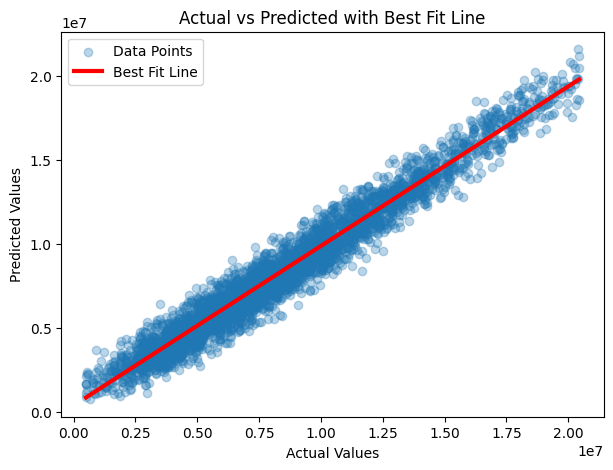

In [93]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Convert to numpy
x = np.array(y_test)
y = np.array(y_pred)

# Scatter plot
plt.scatter(x, y, alpha=0.3, label='Data Points')

# Best fit line
slope, intercept = np.polyfit(x, y, 1)
line = slope * x + intercept

# Sort for smooth line
sorted_idx = np.argsort(x)

plt.plot(x[sorted_idx], line[sorted_idx],
         color='red', linewidth=3, label='Best Fit Line')

# Labels
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted with Best Fit Line")
plt.legend()

plt.show()

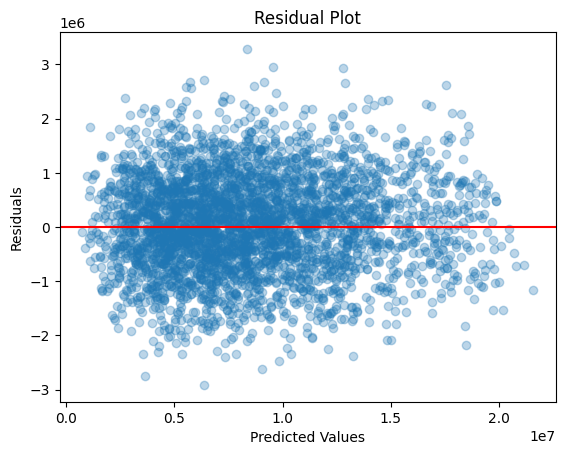

In [94]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

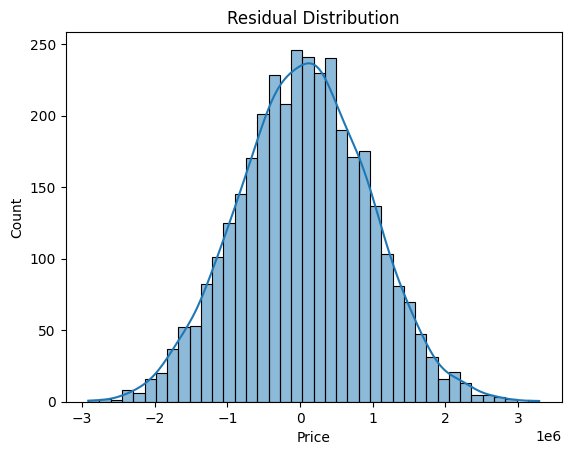

In [95]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()